Cleaned data shape: (1063610, 7)
Temperature column used: value
Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change\monthly_relative_change_2004_2036.csv
         organism    scenario  month  baseline_monthly_dd  \
0   Aedes aegypti  historical      1           174.609354   
1   Aedes aegypti  historical      2           199.873371   
2   Aedes aegypti  historical      3           235.471440   
3   Aedes aegypti  historical      4           377.758377   
4   Aedes aegypti  historical      5           499.434748   
5   Aedes aegypti  historical      6           535.510670   
6   Aedes aegypti  historical      7           609.318450   
7   Aedes aegypti  historical      8           597.276902   
8   Aedes aegypti  historical      9           538.380403   
9   Aedes aegypti  historical     10           425.110073   
10  Aedes aegypti  historical     11           380.572922   
11  Aedes aegypti  historical     12           243.959611   
12  Aedes aegypti  

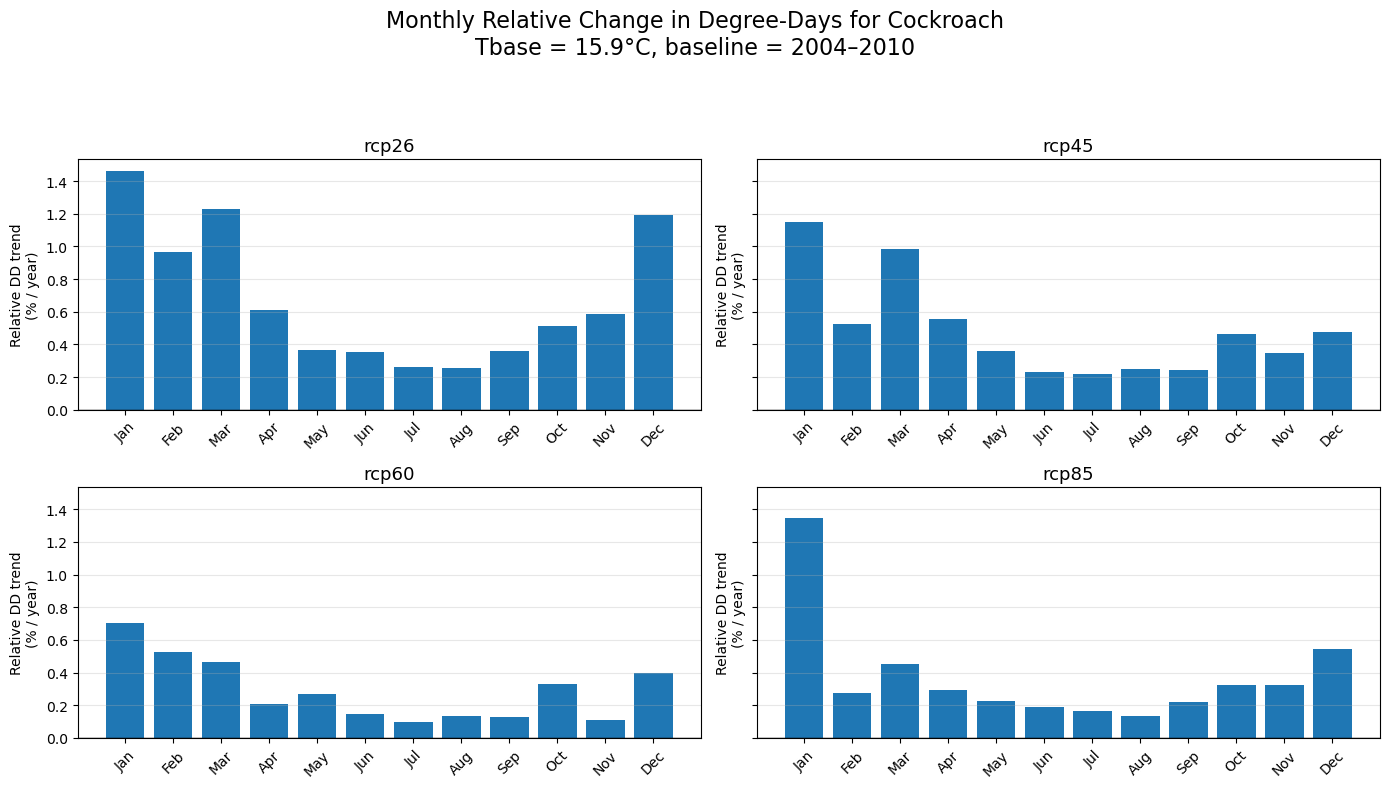

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change\Monthly_relative_DD_trend_Cockroach_2004_2036.png


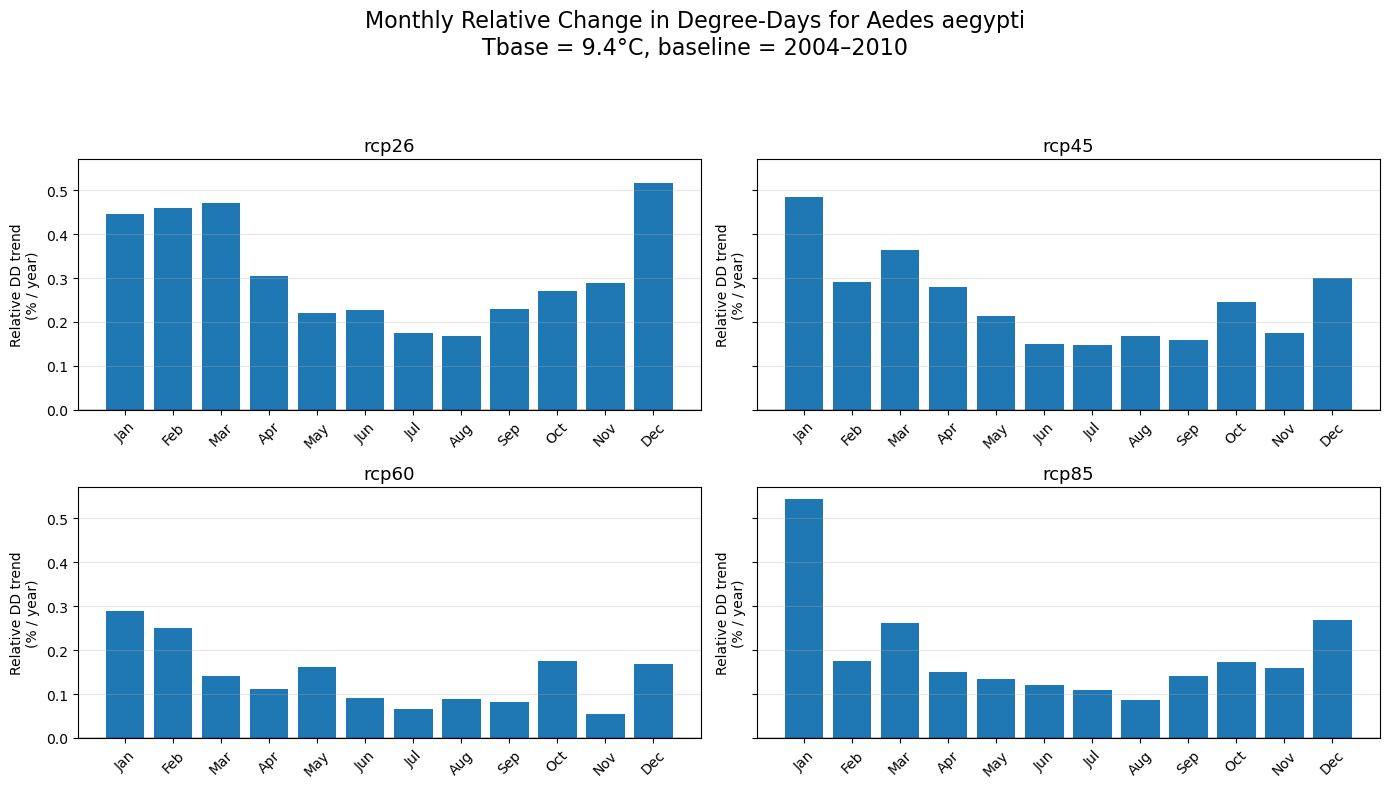

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change\Monthly_relative_DD_trend_Aedes_aegypti_2004_2036.png


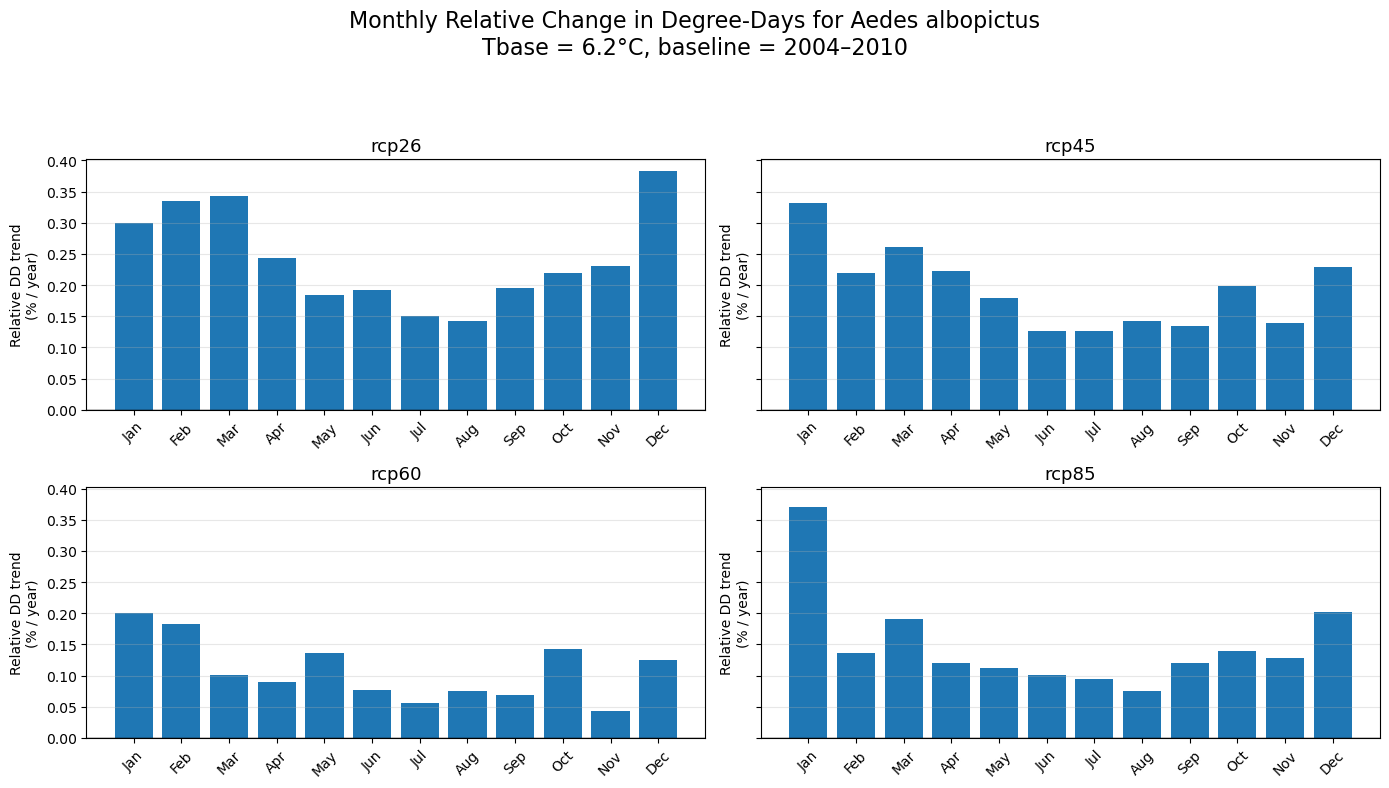

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change\Monthly_relative_DD_trend_Aedes_albopictus_2004_2036.png


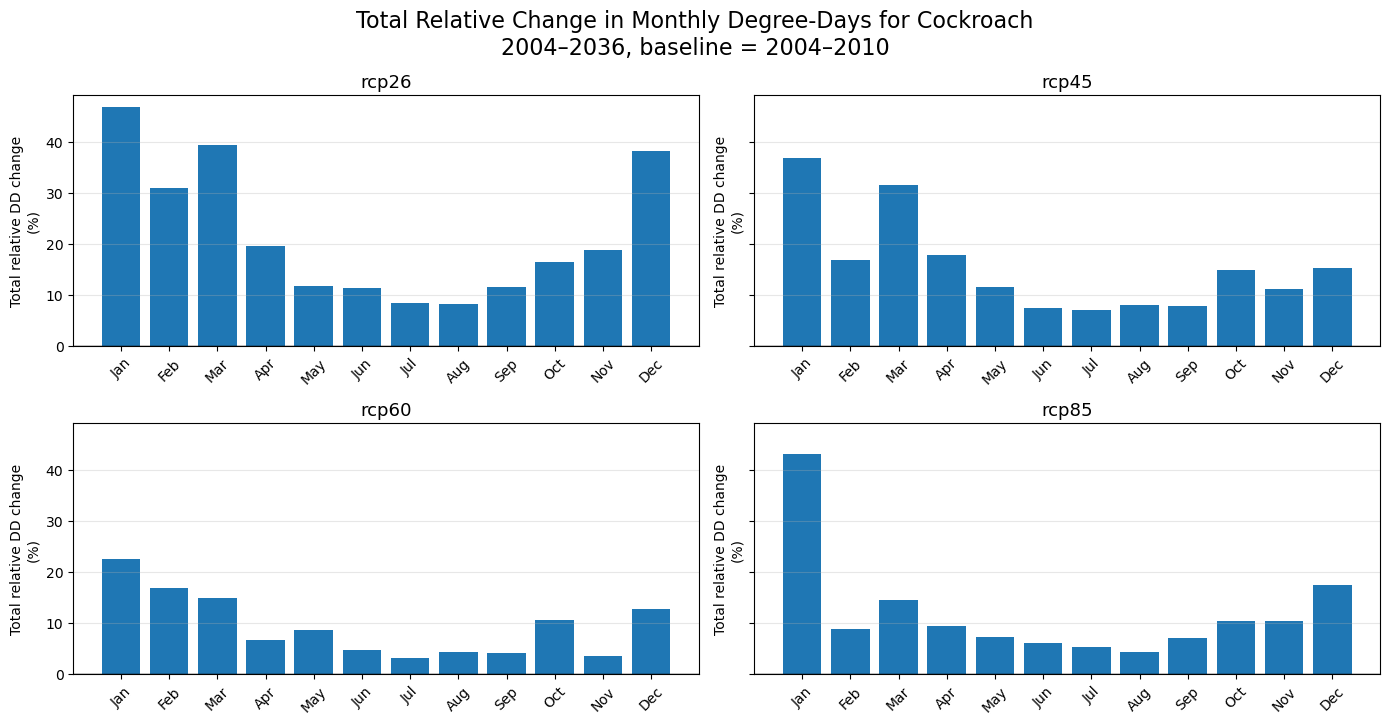

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change\Monthly_total_relative_DD_change_Cockroach_2004_2036.png


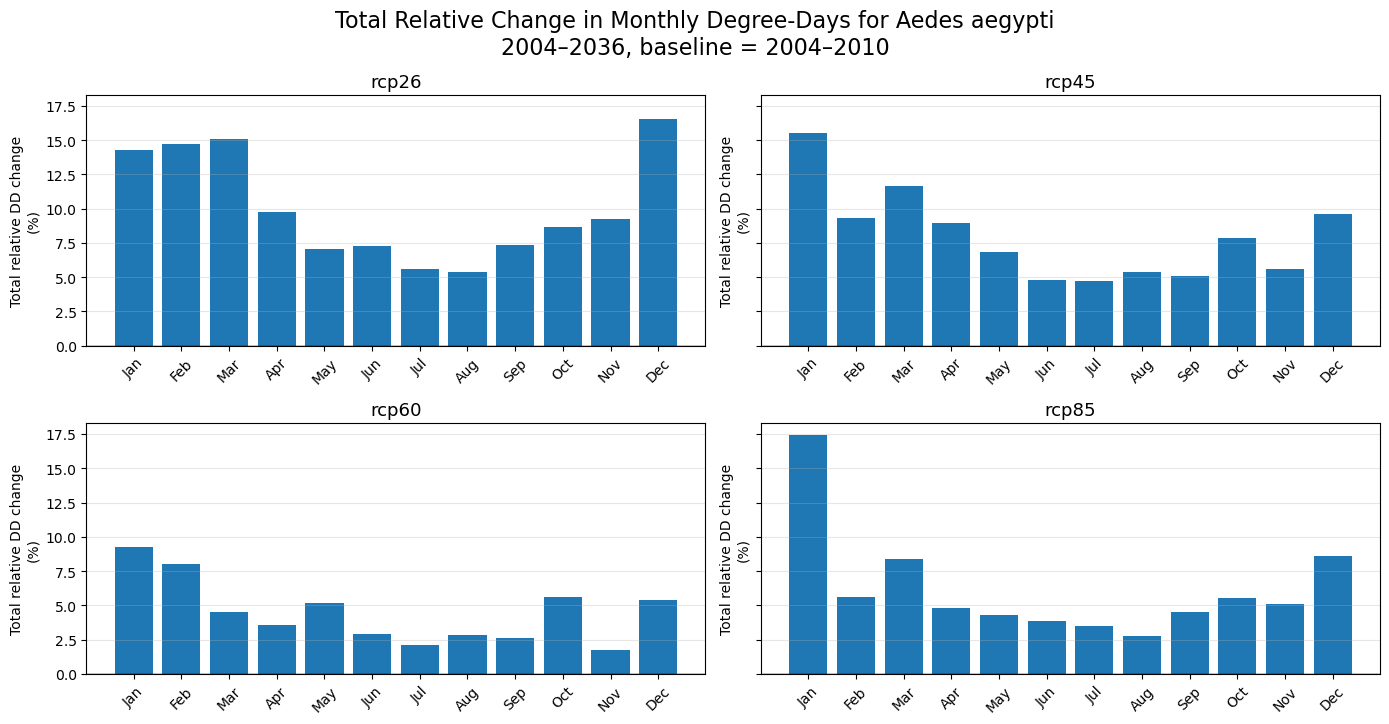

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change\Monthly_total_relative_DD_change_Aedes_aegypti_2004_2036.png


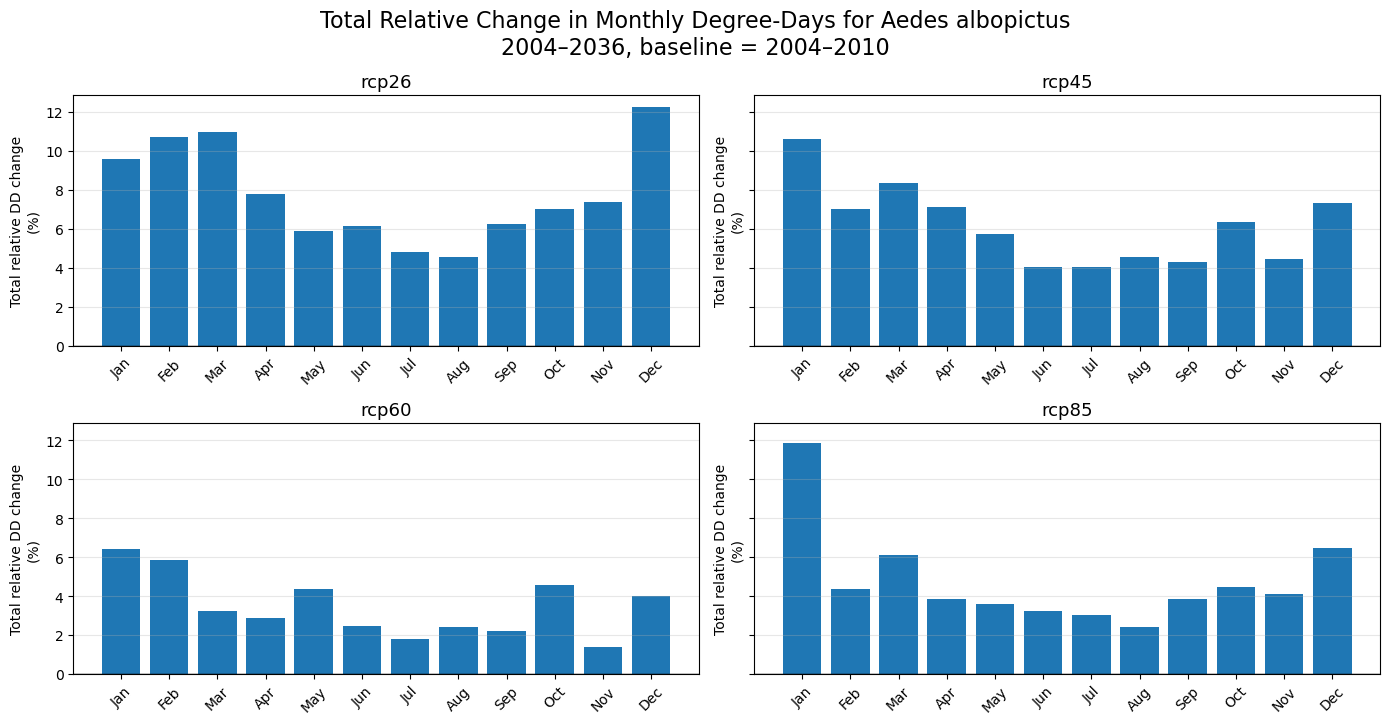

Saved figure: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change\Monthly_total_relative_DD_change_Aedes_albopictus_2004_2036.png


In [4]:
# ============================================================
# Relative Change (% trend) for Monthly DD / Generation
# Cockroach + Aedes aegypti + Aedes albopictus
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Basic settings
# ============================================================

FILE_PATH = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmean_corrected_daily_final_models.parquet"

OUTPUT_DIR = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\monthly_relative_change")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_YEAR = 2004
END_YEAR = 2036

BASELINE_START = 2004
BASELINE_END = 2010

SCENARIO_ORDER = ["rcp26", "rcp45", "rcp60", "rcp85"]

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

ORGANISMS = {
    "Cockroach": {
        "base_temp": 15.9,
        "dd_per_generation": 650
    },
    "Aedes aegypti": {
        "base_temp": 9.4,
        "dd_per_generation": 160
    },
    "Aedes albopictus": {
        "base_temp": 6.2,
        "dd_per_generation": 190
    }
}

# ============================================================
# 2. Read and clean data
# ============================================================

df = pd.read_parquet(FILE_PATH)

df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df["scenario"] = df["scenario"].astype(str).str.lower()
df["model"] = df["model"].astype(str)

temp_col = "value_corrected" if "value_corrected" in df.columns else "value"
df[temp_col] = pd.to_numeric(df[temp_col], errors="coerce")

df = df[
    (df["year"] >= START_YEAR) &
    (df["year"] <= END_YEAR)
].copy()

df = df.dropna(subset=["date", temp_col, "model", "scenario"])
df = df.drop_duplicates(subset=["scenario", "model", "date"])

print("Cleaned data shape:", df.shape)
print("Temperature column used:", temp_col)

# ============================================================
# 3. Calculate monthly DD and generation
# ============================================================

monthly_all = []

for organism, params in ORGANISMS.items():

    temp = df.copy()

    base_temp = params["base_temp"]
    dd_per_generation = params["dd_per_generation"]

    temp["organism"] = organism
    temp["base_temp"] = base_temp
    temp["dd_per_generation"] = dd_per_generation

    temp["dd_daily"] = (temp[temp_col] - base_temp).clip(lower=0)

    monthly = (
        temp
        .groupby(
            ["organism", "scenario", "model", "year", "month",
             "base_temp", "dd_per_generation"],
            as_index=False
        )["dd_daily"]
        .sum()
        .rename(columns={"dd_daily": "monthly_dd"})
    )

    monthly["monthly_generation"] = (
        monthly["monthly_dd"] / monthly["dd_per_generation"]
    )

    monthly_all.append(monthly)

monthly_all = pd.concat(monthly_all, ignore_index=True)

# ============================================================
# 4. Ensemble mean
# ============================================================

ensemble_monthly = (
    monthly_all
    .groupby(["organism", "scenario", "year", "month"], as_index=False)
    .agg(
        ensemble_monthly_dd=("monthly_dd", "mean"),
        ensemble_monthly_generation=("monthly_generation", "mean"),
        n_models=("model", "nunique")
    )
)

# ============================================================
# 5. Calculate Relative Change (% trend)
# ============================================================
# relative trend = slope / baseline mean * 100
# unit: % per year
#
# total relative change = fitted change from START_YEAR to END_YEAR
# unit: %

relative_records = []

for (organism, scenario, month), g in ensemble_monthly.groupby(
    ["organism", "scenario", "month"]
):

    g = g.sort_values("year").copy()

    baseline = g[
        (g["year"] >= BASELINE_START) &
        (g["year"] <= BASELINE_END)
    ]

    baseline_dd = baseline["ensemble_monthly_dd"].mean()
    baseline_gen = baseline["ensemble_monthly_generation"].mean()

    if len(g) >= 2:

        slope_dd, intercept_dd = np.polyfit(
            g["year"],
            g["ensemble_monthly_dd"],
            1
        )

        slope_gen, intercept_gen = np.polyfit(
            g["year"],
            g["ensemble_monthly_generation"],
            1
        )

        fitted_start_dd = slope_dd * START_YEAR + intercept_dd
        fitted_end_dd = slope_dd * END_YEAR + intercept_dd

        fitted_start_gen = slope_gen * START_YEAR + intercept_gen
        fitted_end_gen = slope_gen * END_YEAR + intercept_gen

    else:
        slope_dd = np.nan
        slope_gen = np.nan
        fitted_start_dd = np.nan
        fitted_end_dd = np.nan
        fitted_start_gen = np.nan
        fitted_end_gen = np.nan

    if baseline_dd > 0:
        relative_dd_trend_percent_per_year = slope_dd / baseline_dd * 100
        total_dd_relative_change_percent = (
            (fitted_end_dd - fitted_start_dd) / baseline_dd * 100
        )
    else:
        relative_dd_trend_percent_per_year = np.nan
        total_dd_relative_change_percent = np.nan

    if baseline_gen > 0:
        relative_gen_trend_percent_per_year = slope_gen / baseline_gen * 100
        total_gen_relative_change_percent = (
            (fitted_end_gen - fitted_start_gen) / baseline_gen * 100
        )
    else:
        relative_gen_trend_percent_per_year = np.nan
        total_gen_relative_change_percent = np.nan

    relative_records.append({
        "organism": organism,
        "scenario": scenario,
        "month": month,

        "baseline_monthly_dd": baseline_dd,
        "baseline_monthly_generation": baseline_gen,

        "slope_dd_per_year": slope_dd,
        "slope_generation_per_year": slope_gen,

        "relative_dd_trend_percent_per_year": relative_dd_trend_percent_per_year,
        "relative_generation_trend_percent_per_year": relative_gen_trend_percent_per_year,

        "total_dd_relative_change_percent": total_dd_relative_change_percent,
        "total_generation_relative_change_percent": total_gen_relative_change_percent
    })

relative_trend = pd.DataFrame(relative_records)

relative_trend = relative_trend.sort_values(
    ["organism", "scenario", "month"]
).reset_index(drop=True)

csv_path = OUTPUT_DIR / f"monthly_relative_change_{START_YEAR}_{END_YEAR}.csv"
relative_trend.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("Saved:", csv_path)
print(relative_trend.head(20))

# ============================================================
# 6. Plot 1: Relative DD trend (% / year)
# ============================================================

for organism in ORGANISMS.keys():

    plot_df = relative_trend[
        relative_trend["organism"] == organism
    ].copy()

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 8),
        sharey=True
    )

    axes = axes.flatten()

    for ax, scenario in zip(axes, SCENARIO_ORDER):

        sub = plot_df[plot_df["scenario"] == scenario].copy()

        sub = (
            sub
            .set_index("month")
            .reindex(range(1, 13))
            .reset_index()
        )

        ax.bar(
            sub["month"],
            sub["relative_dd_trend_percent_per_year"]
        )

        ax.axhline(0, color="black", linewidth=1)

        ax.set_title(scenario, fontsize=13)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(MONTH_LABELS, rotation=45)

        ax.set_ylabel("Relative DD trend\n(% / year)")
        ax.grid(axis="y", alpha=0.3)

    base_temp = ORGANISMS[organism]["base_temp"]

    fig.suptitle(
        f"Monthly Relative Change in Degree-Days for {organism}\n"
        f"Tbase = {base_temp}°C, baseline = {BASELINE_START}–{BASELINE_END}",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    safe_name = organism.replace(" ", "_").replace(".", "")

    outpath = OUTPUT_DIR / f"Monthly_relative_DD_trend_{safe_name}_{START_YEAR}_{END_YEAR}.png"

    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", outpath)

# ============================================================
# 7. Plot 2: Total Relative DD Change (%)
# ============================================================

for organism in ORGANISMS.keys():

    plot_df = relative_trend[
        relative_trend["organism"] == organism
    ].copy()

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 8),
        sharey=True
    )

    axes = axes.flatten()

    for ax, scenario in zip(axes, SCENARIO_ORDER):

        sub = plot_df[plot_df["scenario"] == scenario].copy()

        sub = (
            sub
            .set_index("month")
            .reindex(range(1, 13))
            .reset_index()
        )

        ax.bar(
            sub["month"],
            sub["total_dd_relative_change_percent"]
        )

        ax.axhline(0, color="black", linewidth=1)

        ax.set_title(scenario, fontsize=13)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(MONTH_LABELS, rotation=45)

        ax.set_ylabel("Total relative DD change\n(%)")
        ax.grid(axis="y", alpha=0.3)

    base_temp = ORGANISMS[organism]["base_temp"]

    fig.suptitle(
        f"Total Relative Change in Monthly Degree-Days for {organism}\n"
        f"{START_YEAR}–{END_YEAR}, baseline = {BASELINE_START}–{BASELINE_END}",
        fontsize=16,y = 0.9
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    safe_name = organism.replace(" ", "_").replace(".", "")

    outpath = OUTPUT_DIR / f"Monthly_total_relative_DD_change_{safe_name}_{START_YEAR}_{END_YEAR}.png"

    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", outpath)